# Linear Regression From Scratch

A beginner-friendly implementation of **Linear Regression using NumPy**, built without using a machine-learning library.

### What this notebook covers
- Creating a simple dataset
- Understanding the linear regression equation
- Making predictions
- Implementing the Mean Squared Error cost function
- Implementing Gradient Descent
- Training the model
- Making predictions on new data
- Visualizing the fitted regression line

### Model

$$
\hat{y} = wx + b
$$

Where:
- $w$ = weight / slope
- $b$ = bias / intercept
- $x$ = input feature
- $\hat{y}$ = predicted value

## 1. Import Required Libraries

We use **NumPy** for numerical calculations and **Matplotlib** for visualization.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Create the Dataset

For this example:

- `x` represents the input feature.
- `y` represents the target value.

The data shows a roughly linear relationship between `x` and `y`.

In [3]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([35, 42, 50, 58, 65, 72, 80, 88])

print("Input:", x)
print("Target:", y)

Input: [1 2 3 4 5 6 7 8]
Target: [35 42 50 58 65 72 80 88]


## 3. Understand the Linear Regression Model

The prediction equation is:

$$
\hat{y} = wx + b
$$

The function below calculates the predicted value for a given `x`, `w`, and `b`.

In [4]:
def predict(x, w, b):
    return w * x + b

# Example parameters
w = 7
b = 30

prediction = predict(5, w, b)
print("Prediction for x = 5:", prediction)

Prediction for x = 5: 65


## 4. Implement the Cost Function

The cost function tells us **how far the model's predictions are from the actual values**.

For linear regression, we use:

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

A lower cost means the model's predictions are closer to the actual values.

In [5]:
def compute_cost(x, y, w, b):
    m = len(x)

    predictions = w * x + b
    errors = predictions - y
    squared_errors = errors ** 2

    cost = (1 / (2 * m)) * np.sum(squared_errors)
    return cost

In [6]:
w = 7
b = 30

cost = compute_cost(x, y, w, b)
print("Cost:", cost)

Cost: 0.875


## 5. Implement Gradient Descent

Gradient Descent is used to find values of `w` and `b` that minimize the cost function.

At every iteration:

1. Calculate predictions.
2. Calculate the error.
3. Calculate the gradients.
4. Update `w` and `b`.
5. Repeat.

The update rules are:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

In [7]:
def gradient_descent(x, y, w, b, learning_rate, iterations):
    m = len(x)

    for _ in range(iterations):
        predictions = w * x + b
        error = predictions - y

        dj_dw = (1 / m) * np.sum(error * x)
        dj_db = (1 / m) * np.sum(error)

        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

    return w, b

## 6. Train the Model

We start with:

- `w = 0`
- `b = 0`

Then Gradient Descent updates them repeatedly until the model learns a good linear relationship.

In [8]:
w = 0
b = 0

learning_rate = 0.01
iterations = 1000

w, b = gradient_descent(
    x, y, w, b,
    learning_rate,
    iterations
)

print("Learned weight (w):", w)
print("Learned bias (b):", b)

Learned weight (w): 8.154065661041614
Learned bias (b): 23.876085025446645


## 7. Evaluate the Trained Model

Let's calculate the cost again after training.

If Gradient Descent worked correctly, the final cost should be much smaller than the initial cost.

In [9]:
initial_cost = compute_cost(x, y, 0, 0)
final_cost = compute_cost(x, y, w, b)

print("Initial cost:", initial_cost)
print("Final cost:", final_cost)

Initial cost: 2025.375
Final cost: 1.2535849950423175


## 8. Make a Prediction

Now that the model has learned `w` and `b`, we can use it to predict the target value for a new input.

Here, we predict the score for `x = 9`.

In [10]:
new_x = 9
prediction = predict(new_x, w, b)

print(f"Predicted score for x = {new_x}: {prediction:.2f}")

Predicted score for x = 9: 97.26


## 9. Visualize the Regression Line

The scatter plot shows the original data points.

The line represents the relationship learned by the Linear Regression model.

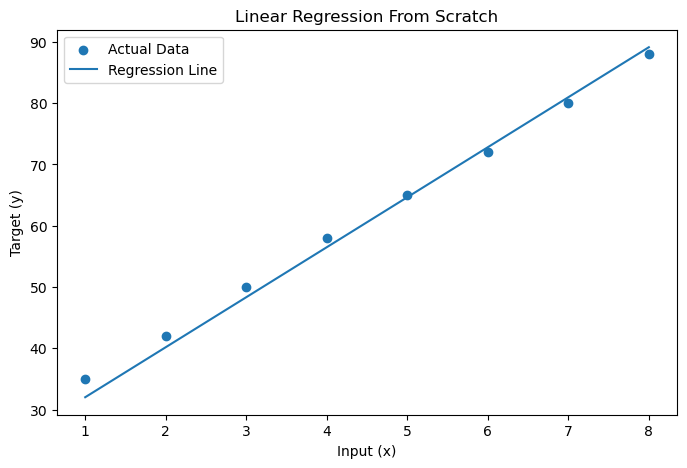

In [14]:
predictions = predict(x, w, b)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Actual Data")
plt.plot(x, predictions, label="Regression Line")
plt.xlabel("Input (x)")
plt.ylabel("Target (y)")

plt.title("Linear Regression From Scratch")
plt.legend()

plt.show()

## 10. Key Takeaways

- Linear Regression learns a relationship between an input and a continuous target.
- The model used here is $\hat{y} = wx + b$.
- The **cost function** measures prediction error.
- **Gradient Descent** updates `w` and `b` to reduce the cost.
- NumPy is enough to implement the core algorithm from scratch.
- This implementation helps build the foundation needed before using libraries such as Scikit-learn.
